In [1]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from xgboost import plot_importance
import matplotlib.pyplot as plt

model_data = pd.read_csv("data/processed/test_training_data.csv")
print(model_data.shape)
model_data.head()

(1963, 18)


,"last_name, first_name",player_id,year,hit,single,double,triple,home_run,strikeout,walk,b_rbi,b_total_bases,r_total_stolen_base,r_run,season,fantasy_points,next_season_points,next_season
0,"Abrams, CJ",682928,2022,70,54,12,2,2,50,5,21,92,7,33,2022,108,340.0,2023.0
1,"Abrams, CJ",682928,2023,138,86,28,6,18,118,32,64,232,47,83,2023,340,321.0,2024.0
2,"Abrams, CJ",682928,2024,133,78,29,6,20,128,40,65,234,31,79,2024,321,346.0,2025.0
3,"Abreu, José",547989,2015,178,111,34,3,30,140,39,101,308,0,88,2015,396,381.0,2016.0
4,"Abreu, José",547989,2016,183,125,32,1,25,125,47,100,292,0,67,2016,381,459.0,2017.0


In [2]:
model_data.isnull().sum() #find empty data

last_name, first_name    0
player_id                0
year                     0
hit                      0
single                   0
double                   0
triple                   0
home_run                 0
strikeout                0
walk                     0
b_rbi                    0
b_total_bases            0
r_total_stolen_base      0
r_run                    0
season                   0
fantasy_points           0
next_season_points       0
next_season              0
dtype: int64

In [3]:
model_data["gap"] = model_data["next_season"] - model_data["year"]
model_data["gap"].value_counts()

gap
1.0    1625
2.0     268
3.0      53
4.0      11
6.0       3
5.0       3
Name: count, dtype: int64

In [4]:
model_data = model_data[model_data["gap"] == 1.0].copy() #remove year gaps (ex: 2021 - 2023)
print(model_data.shape)
model_data["gap"].value_counts()

(1625, 19)


gap
1.0    1625
Name: count, dtype: int64

In [5]:
features = [
    "single",
    "double", 
    "triple",
    "home_run",
    "strikeout",
    "walk",
    "b_rbi",
    "r_total_stolen_base",
    "r_run",
    "fantasy_points"
]
target = "next_season_points"

x = model_data[features]
y = model_data[target]

print(x.shape)
print(y.describe())

(1625, 10)
count    1625.000000
mean      281.920615
std       108.665848
min        58.000000
25%       197.000000
50%       270.000000
75%       356.000000
max       707.000000
Name: next_season_points, dtype: float64


In [6]:
train = model_data[model_data["year"] < 2024] #data used for traning
test = model_data[model_data["year"] == 2024] #data used for testing (precict 2025 points)

x_train = train[features] #current season points (pre-2024)
x_test = test[features]
y_train = train[target] #next season points (pre-2024)
y_test = test[target]

print(f"training row: {len(train)}")
print(f"testing row: {len(test)}")

training row: 1426
testing row: 199


In [7]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model.fit(x_train, y_train)

y_predict = model.predict(x_test)

mae = mean_absolute_error(y_test, y_predict)
print(f"Mean Absolute Error: {mae:.1f} fantasy points")

Mean Absolute Error: 70.1 fantasy points


In [8]:
result1 = test[["last_name, first_name", "year", "fantasy_points"]].copy()
result1["predicted"] = y_predict.round(1)
result1["actual"] = y_test.values
result1["error"] = (result1["predicted"] - result1["actual"]).abs()
result1.sort_values("error", ascending=False).head(10)

,"last_name, first_name",year,fantasy_points,predicted,actual,error
1435,"Raleigh, Cal",2024,311,275.899994,509.0,233.100006
1350,"Perdomo, Geraldo",2024,211,284.399994,512.0,227.600006
938,"Judge, Aaron",2024,630,374.299988,599.0,224.700012
1519,"Rodríguez, Julio",2024,282,220.899994,432.0,211.100006
184,"Bichette, Bo",2024,121,206.399994,406.0,199.600006
1751,"Tatis Jr., Fernando",2024,256,247.199997,439.0,191.800003
209,"Bohm, Alec",2024,366,435.700012,251.0,184.700012
1289,"Ohtani, Shohei",2024,653,388.000000,570.0,182.000000
49,"Alonso, Pete",2024,359,258.899994,440.0,181.100006
1658,"Soler, Jorge",2024,294,281.500000,107.0,174.500000


In [9]:
data_set_2 = pd.read_csv("../data/raw/savant_model2.csv")

print(data_set_2.shape)
data_set_2.head()

(2769, 16)


,"last_name, first_name",player_id,year,player_age,pa,home_run,k_percent,bb_percent,r_total_stolen_base,xba,xslg,xwoba,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_hyper_speed
0,"Hunter, Torii",116338,2015,39,567,22,18.5,6.2,2,0.229,0.370,0.290,28.5,5.6,34.9,93.393480
1,"Ortiz, David",120074,2015,39,614,37,15.5,12.5,0,0.301,0.616,0.420,34.8,14.6,49.1,96.053058
2,"Rodriguez, Alex",121347,2015,39,620,33,23.4,13.5,4,0.247,0.494,0.368,31.4,11.8,43.9,95.014380
3,"Ramirez, Aramis",133380,2015,37,516,17,13.2,6.0,1,0.240,0.405,0.304,33.5,6.1,34.5,92.944763
4,"Beltré, Adrian",134181,2015,36,619,18,10.5,6.6,1,0.295,0.482,0.360,35.7,5.8,40.4,93.842412


In [10]:
model_data_2 = model_data.merge(data_set_2[[
    "player_id", "year", "player_age", "pa", "k_percent", "bb_percent", "xba", "xslg", 
    "xwoba", "sweet_spot_percent", "barrel_batted_rate","hard_hit_percent", "avg_hyper_speed"]],
    on=["player_id", "year"], how="inner"
)
print(model_data_2.shape)
model_data_2.head()



(1625, 30)


,"last_name, first_name",player_id,year,hit,single,double,triple,home_run,strikeout,walk,...,pa,k_percent,bb_percent,xba,xslg,xwoba,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_hyper_speed
0,"Abrams, CJ",682928,2022,70,54,12,2,2,50,5,...,302,16.6,1.7,0.244,0.327,0.272,28.6,2.1,30.7,92.612726
1,"Abrams, CJ",682928,2023,138,86,28,6,18,118,32,...,614,19.2,5.2,0.243,0.402,0.304,32.6,6.9,35.9,93.426357
2,"Abrams, CJ",682928,2024,133,78,29,6,20,128,40,...,602,21.3,6.6,0.243,0.413,0.320,33.0,7.0,40.7,93.910198
3,"Abreu, José",547989,2015,178,111,34,3,30,140,39,...,668,21.0,5.8,0.270,0.456,0.338,30.4,10.6,41.8,95.406299
4,"Abreu, José",547989,2016,183,125,32,1,25,125,47,...,695,18.0,6.8,0.280,0.467,0.348,32.7,8.6,39.4,94.406076


In [11]:
#model_data["gap"] = model_data["next_season"] - model_data["year"]
model_data_2["gap"] = model_data_2["next_season"] - model_data_2["year"]
model_data_2 = model_data_2[model_data_2["gap"] == 1.0].copy()
print(model_data_2.shape)
print(model_data_2.columns.tolist())

(1625, 30)
['last_name, first_name', 'player_id', 'year', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout', 'walk', 'b_rbi', 'b_total_bases', 'r_total_stolen_base', 'r_run', 'season', 'fantasy_points', 'next_season_points', 'next_season', 'gap', 'player_age', 'pa', 'k_percent', 'bb_percent', 'xba', 'xslg', 'xwoba', 'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent', 'avg_hyper_speed']


In [12]:
features_2 = ["player_age", "pa", "home_run", "r_total_stolen_base", "k_percent", 
            "bb_percent", "xba", "xslg", "xwoba", "sweet_spot_percent", "barrel_batted_rate",
            "hard_hit_percent", "avg_hyper_speed", "fantasy_points"]
target = "next_season_points"

x_train_2 = model_data_2[model_data_2["year"] < 2024][features_2]
x_test_2 = model_data_2[model_data_2["year"] == 2024][features_2]
y_train_2 = model_data_2[model_data_2["year"] < 2024][target]
y_test_2 = model_data_2[model_data_2["year"] == 2024][target]

print(f"training: {len(x_train_2)}")
print(f"testing: {len(x_test_2)}")

training: 1426
testing: 199


In [13]:
model_2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_2.fit(x_train_2, y_train_2)
y_prediction_2 = model_2.predict(x_test_2)

mae_2 = mean_absolute_error(y_test_2, y_prediction_2)
print(f"Model 1 MAE: {mae: .1f}")
print(f"Model 2 MAE: {mae_2: .1f}")
print(f"Difference: {mae - mae_2: .1f}")

Model 1 MAE:  70.1
Model 2 MAE:  66.2
Difference:  4.0


In [14]:
result2 = test[["last_name, first_name", "year", "fantasy_points"]].copy()
result2["predicted"] = y_prediction_2.round(1)
result2["actual"] = y_test_2.values
result2["error"] = (result2["predicted"] - result2["actual"]).abs()
result2.sort_values("error", ascending=False).head(10)

,"last_name, first_name",year,fantasy_points,predicted,actual,error
1350,"Perdomo, Geraldo",2024,211,264.100006,512.0,247.899994
1435,"Raleigh, Cal",2024,311,298.200012,509.0,210.799988
938,"Judge, Aaron",2024,630,392.600006,599.0,206.399994
1401,"Polanco, Jorge",2024,149,141.500000,341.0,199.500000
1289,"Ohtani, Shohei",2024,653,375.100006,570.0,194.899994
1796,"Tovar, Ezequiel",2024,297,341.500000,149.0,192.500000
1681,"Springer, George",2024,293,255.199997,445.0,189.800003
1587,"Schwarber, Kyle",2024,406,323.700012,504.0,180.299988
401,"Cowser, Colton",2024,258,295.200012,115.0,180.200012
260,"Buxton, Byron",2024,232,187.600006,366.0,178.399994


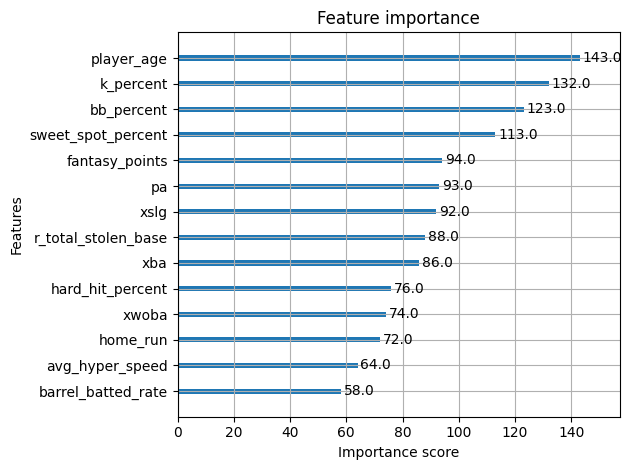

In [15]:
plot_importance(model_2 , max_num_features=14)
plt.tight_layout()
plt.show()

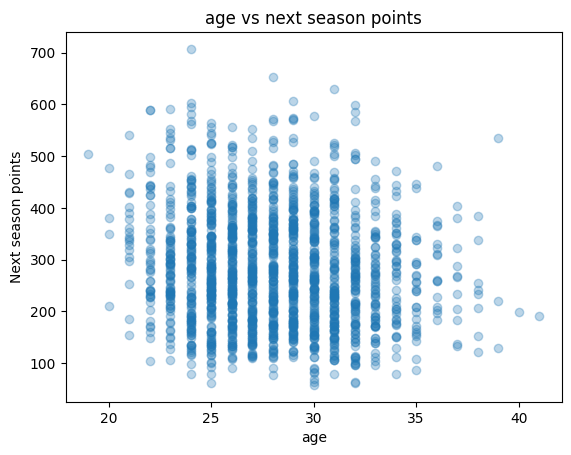

In [16]:
plt.scatter(model_data_2["player_age"], model_data_2["next_season_points"], alpha=0.3)
plt.xlabel("age")
plt.ylabel("Next season points")
plt.title("age vs next season points")
plt.show()

In [17]:
data_set_3 = pd.read_csv("../data/raw/savant_model3.csv")

print(data_set_3.shape)
data_set_3.head()

(2769, 16)


,"last_name, first_name",player_id,year,pa,home_run,k_percent,bb_percent,r_total_stolen_base,xba,xslg,xwoba,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_hyper_speed,whiff_percent
0,"Hunter, Torii",116338,2015,567,22,18.5,6.2,2,0.229,0.370,0.290,28.5,5.6,34.9,93.393480,23.1
1,"Ortiz, David",120074,2015,614,37,15.5,12.5,0,0.301,0.616,0.420,34.8,14.6,49.1,96.053058,23.2
2,"Rodriguez, Alex",121347,2015,620,33,23.4,13.5,4,0.247,0.494,0.368,31.4,11.8,43.9,95.014380,32.0
3,"Ramirez, Aramis",133380,2015,516,17,13.2,6.0,1,0.240,0.405,0.304,33.5,6.1,34.5,92.944763,17.9
4,"Beltré, Adrian",134181,2015,619,18,10.5,6.6,1,0.295,0.482,0.360,35.7,5.8,40.4,93.842412,16.8


In [18]:
model_data_3 = model_data.merge(data_set_3[[ # Remove Age, add whiff%
    "player_id", "year", "pa", "k_percent", "bb_percent", "xba", "xslg", 
    "xwoba", "sweet_spot_percent", "barrel_batted_rate","hard_hit_percent", "avg_hyper_speed", "whiff_percent"]],
    on=["player_id", "year"], how="inner"
)
print(model_data_3.shape)
model_data_3.head()

(1625, 30)


,"last_name, first_name",player_id,year,hit,single,double,triple,home_run,strikeout,walk,...,k_percent,bb_percent,xba,xslg,xwoba,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_hyper_speed,whiff_percent
0,"Abrams, CJ",682928,2022,70,54,12,2,2,50,5,...,16.6,1.7,0.244,0.327,0.272,28.6,2.1,30.7,92.612726,22.6
1,"Abrams, CJ",682928,2023,138,86,28,6,18,118,32,...,19.2,5.2,0.243,0.402,0.304,32.6,6.9,35.9,93.426357,22.5
2,"Abrams, CJ",682928,2024,133,78,29,6,20,128,40,...,21.3,6.6,0.243,0.413,0.320,33.0,7.0,40.7,93.910198,24.7
3,"Abreu, José",547989,2015,178,111,34,3,30,140,39,...,21.0,5.8,0.270,0.456,0.338,30.4,10.6,41.8,95.406299,24.9
4,"Abreu, José",547989,2016,183,125,32,1,25,125,47,...,18.0,6.8,0.280,0.467,0.348,32.7,8.6,39.4,94.406076,23.8


In [19]:
model_data_3["gap"] = model_data_3["next_season"] - model_data_3["year"]
model_data_3 = model_data_3[model_data_3["gap"] == 1.0].copy()
print(model_data_3.shape)
print(model_data_3.columns.tolist())

(1625, 30)
['last_name, first_name', 'player_id', 'year', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout', 'walk', 'b_rbi', 'b_total_bases', 'r_total_stolen_base', 'r_run', 'season', 'fantasy_points', 'next_season_points', 'next_season', 'gap', 'pa', 'k_percent', 'bb_percent', 'xba', 'xslg', 'xwoba', 'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent', 'avg_hyper_speed', 'whiff_percent']


In [20]:
features_3 = ["pa", "home_run", "r_total_stolen_base", "k_percent", 
            "bb_percent", "xba", "xslg", "xwoba", "sweet_spot_percent", "barrel_batted_rate",
            "hard_hit_percent", "avg_hyper_speed", "whiff_percent", "fantasy_points"]
target = "next_season_points"

x_train_3 = model_data_3[model_data_3["year"] < 2024][features_3]
x_test_3 = model_data_3[model_data_3["year"] == 2024][features_3]
y_train_3 = model_data_3[model_data_3["year"] < 2024][target]
y_test_3 = model_data_3[model_data_3["year"] == 2024][target]

print(f"training: {len(x_train_3)}")
print(f"testing: {len(x_test_3)}")

training: 1426
testing: 199


In [21]:
model_3 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_3.fit(x_train_3, y_train_3)
y_prediction_3 = model_3.predict(x_test_3)

mae_3 = mean_absolute_error(y_test_3, y_prediction_3)
print(f"Model 2 MAE: {mae_2: .1f}")
print(f"Model 3 MAE: {mae_3: .1f}")
print(f"Difference: {mae_2 - mae_3: .1f}")

Model 2 MAE:  66.2
Model 3 MAE:  65.7
Difference:  0.5


In [22]:
result3 = test[["last_name, first_name", "year", "fantasy_points"]].copy()
result3["predicted"] = y_prediction_3.round(1)
result3["actual"] = y_test_3.values
result3["error"] = (result3["predicted"] - result3["actual"]).abs()
result3.sort_values("error", ascending=False).head(10)

,"last_name, first_name",year,fantasy_points,predicted,actual,error
1435,"Raleigh, Cal",2024,311,268.700012,509.0,240.299988
938,"Judge, Aaron",2024,630,365.399994,599.0,233.600006
1350,"Perdomo, Geraldo",2024,211,288.600006,512.0,223.399994
1289,"Ohtani, Shohei",2024,653,360.700012,570.0,209.299988
1334,"Pederson, Joc",2024,272,301.500000,112.0,189.500000
1419,"Profar, Jurickson",2024,423,419.899994,235.0,184.899994
1658,"Soler, Jorge",2024,294,287.399994,107.0,180.399994
1796,"Tovar, Ezequiel",2024,297,328.799988,149.0,179.799988
1681,"Springer, George",2024,293,272.399994,445.0,172.600006
1221,"Mountcastle, Ryan",2024,234,275.700012,111.0,164.700012


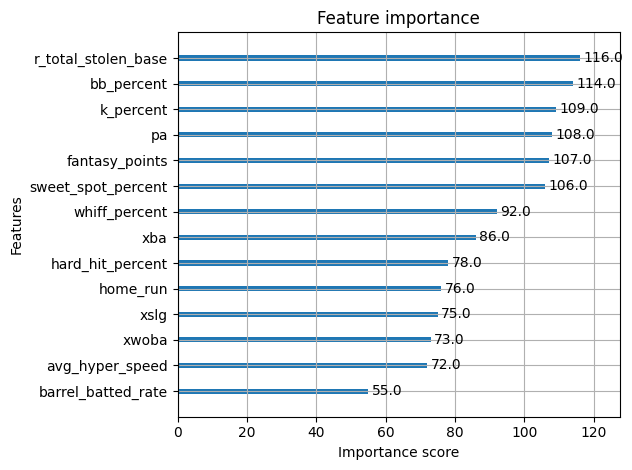

In [23]:
plot_importance(model_3 , max_num_features=14)
plt.tight_layout()
plt.show()

In [24]:
model_data_4 = model_data.merge(data_set_3[[ # Remove stolen bases
    "player_id", "year", "pa", "k_percent", "bb_percent", "xba", "xslg", 
    "xwoba", "sweet_spot_percent", "barrel_batted_rate","hard_hit_percent", "avg_hyper_speed", "whiff_percent"]],
    on=["player_id", "year"], how="inner"
)


In [25]:
model_data_4["gap"] = model_data_4["next_season"] - model_data_4["year"]
model_data_4 = model_data_4[model_data_4["gap"] == 1.0].copy()
print(model_data_4.shape)
print(model_data_4.columns.tolist())

(1625, 30)
['last_name, first_name', 'player_id', 'year', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout', 'walk', 'b_rbi', 'b_total_bases', 'r_total_stolen_base', 'r_run', 'season', 'fantasy_points', 'next_season_points', 'next_season', 'gap', 'pa', 'k_percent', 'bb_percent', 'xba', 'xslg', 'xwoba', 'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent', 'avg_hyper_speed', 'whiff_percent']


In [26]:
features_4 = ["pa", "home_run", "k_percent", 
            "bb_percent", "xba", "xslg", "xwoba", "sweet_spot_percent", "barrel_batted_rate",
            "hard_hit_percent", "avg_hyper_speed", "whiff_percent", "fantasy_points"]
target = "next_season_points"

x_train_4 = model_data_4[model_data_4["year"] < 2024][features_4]
x_test_4 = model_data_4[model_data_4["year"] == 2024][features_4]
y_train_4 = model_data_4[model_data_4["year"] < 2024][target]
y_test_4 = model_data_4[model_data_4["year"] == 2024][target]

print(f"training: {len(x_train_4)}")
print(f"testing: {len(x_test_4)}")

training: 1426
testing: 199


In [27]:
model_4 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_4.fit(x_train_4, y_train_4)
y_prediction_4 = model_4.predict(x_test_4)

mae_4 = mean_absolute_error(y_test_4, y_prediction_4)
print(f"Model 3 MAE: {mae_3: .1f}")
print(f"Model 4 MAE: {mae_4: .1f}")
print(f"Difference: {mae_3 - mae_4: .1f}")

Model 3 MAE:  65.7
Model 4 MAE:  67.8
Difference: -2.2


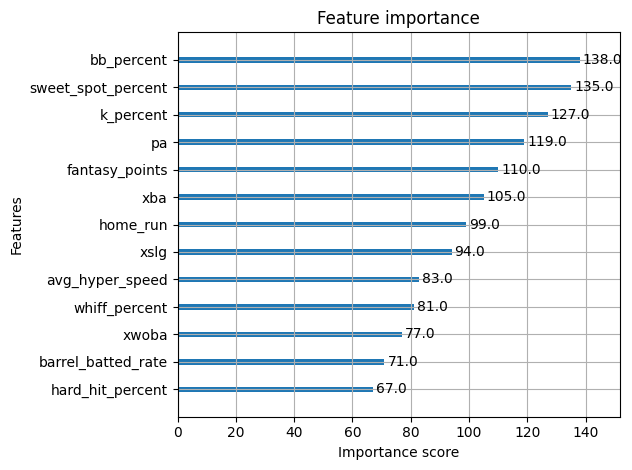

In [28]:
plot_importance(model_4 , max_num_features=14)
plt.tight_layout()
plt.show()

In [29]:
result4 = test[["last_name, first_name", "year", "fantasy_points"]].copy()
result4["predicted"] = y_prediction_4.round(1)
result4["actual"] = y_test_4.values
result4["error"] = (result4["predicted"] - result4["actual"]).abs()
result4.sort_values("error", ascending=False).head(10)

,"last_name, first_name",year,fantasy_points,predicted,actual,error
938,"Judge, Aaron",2024,630,336.000000,599.0,263.000000
1350,"Perdomo, Geraldo",2024,211,274.100006,512.0,237.899994
1435,"Raleigh, Cal",2024,311,273.299988,509.0,235.700012
1289,"Ohtani, Shohei",2024,653,351.700012,570.0,218.299988
1796,"Tovar, Ezequiel",2024,297,353.500000,149.0,204.500000
1658,"Soler, Jorge",2024,294,307.000000,107.0,200.000000
425,"Crow-Armstrong, Pete",2024,186,202.000000,379.0,177.000000
184,"Bichette, Bo",2024,121,231.100006,406.0,174.899994
1419,"Profar, Jurickson",2024,423,405.100006,235.0,170.100006
1681,"Springer, George",2024,293,275.500000,445.0,169.500000


In [30]:
data_set5 = pd.read_csv("../data/raw/savant_model5.csv")
print(data_set5.shape)
data_set5.head()
data_set5.columns

(2769, 39)


Index(['last_name, first_name', 'player_id', 'year', 'player_age', 'ab', 'pa',
       'single', 'double', 'triple', 'home_run', 'strikeout', 'walk',
       'k_percent', 'bb_percent', 'batting_avg', 'slg_percent',
       'on_base_percent', 'on_base_plus_slg', 'isolated_power', 'b_rbi',
       'r_total_caught_stealing', 'r_total_stolen_base', 'r_run',
       'r_stolen_base_pct', 'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'xiso',
       'exit_velocity_avg', 'sweet_spot_percent', 'barrel_batted_rate',
       'hard_hit_percent', 'avg_hyper_speed', 'oz_swing_miss_percent',
       'whiff_percent', 'swing_percent', 'sprint_speed'],
      dtype='str')

In [31]:
data_set5['fantasy_points'] = (
    data_set5['single'] * 1 +
    data_set5['double'] * 2 +
    data_set5['triple'] * 3 +
    data_set5['home_run'] * 4 +
    data_set5['walk'] * 1 +
    data_set5['strikeout'] * -1 +
    data_set5['b_rbi'] * 1 +
    data_set5['r_run'] * 1 +
    data_set5['r_total_stolen_base'] * 1
)

In [32]:
print(data_set5[['last_name, first_name', 'year', 'fantasy_points']].sort_values('fantasy_points', ascending=False).head(10))

     last_name, first_name  year  fantasy_points
2072     Acuña Jr., Ronald  2023             707
2333        Ohtani, Shohei  2024             653
2242          Judge, Aaron  2024             630
1712          Judge, Aaron  2022             607
1295         Bregman, Alex  2019             603
2518          Judge, Aaron  2025             599
1048         Ramírez, José  2018             594
2446       Witt Jr., Bobby  2024             590
1325       Bellinger, Cody  2019             589
515          Betts, Mookie  2016             589


In [41]:
counting_stats = ['home_run', 'single', 'double', 'triple', 
              'b_rbi', 'r_run', ]
for stat in counting_stats:
    data_set5[f'{stat}_per_pa'] = data_set5[stat] / data_set5['pa']
    
lag_stats = [
    'pa', 'xwoba', 'xba', 'xslg', 'xobp', 'xiso',
    'k_percent', 'bb_percent','home_run_per_pa', 'single_per_pa', 
    'double_per_pa', 'triple_per_pa', 'b_rbi_per_pa', 
    'r_run_per_pa', 'r_total_stolen_base', 'barrel_batted_rate',
    'hard_hit_percent', 'sweet_spot_percent', 'avg_hyper_speed',
    'whiff_percent', 'sprint_speed', 'exit_velocity_avg',
    'home_run', 'single', 'double', 'triple', 'walk',
    'strikeout', 'b_rbi', 'r_run', 'r_total_stolen_base',
    'fantasy_points'
]   
target_years = list(range(2017, 2025))
rows = []

for year in target_years:
    total_years = [y for y in range(2015, year) if y != 2020] #2020 not included in data
    y1 = total_years[-1] #if target year is 2019, get 2018
    if len(total_years) > 1:
        y2 = total_years[-2]
    else:
        y2 = None
    if len(total_years) > 2:
        y3 = total_years[-3]
    else:
        y3 = None
    players_y1 = data_set5[data_set5['year'] == y1]['player_id'].unique()

    for player in players_y1:
        player_data = data_set5[data_set5['player_id'] == player]
        y1_data = player_data[player_data['year'] == y1]
        if y2 is not None:
            y2_data = player_data[player_data['year'] == y2]
        else:
            y2_data = pd.DataFrame()
        if y3 is not None:
            y3_data = player_data[player_data['year'] == y3]
        else:
            y3_data = pd.DataFrame()
                
        if y1_data.empty or (y2_data.empty and y3_data.empty):
            continue
        target_data = data_set5[(data_set5['player_id'] == player) &
            (data_set5['year'] == year)
            ]
        if target_data.empty:
            continue

        row = {'player_id': player,
                'player_name': y1_data['last_name, first_name'].values[0],
                'target_year': year,
                'player_age': y1_data['player_age'].values[0]+1,
                'target_pa': target_data['pa'].values[0],
                'target_home_run_per_pa': target_data['home_run_per_pa'].values[0],
                'target_single_per_pa': target_data['single_per_pa'].values[0],
                'target_double_per_pa': target_data['double_per_pa'].values[0],
                'target_triple_per_pa': target_data['triple_per_pa'].values[0],
                'target_b_rbi_per_pa': target_data['b_rbi_per_pa'].values[0],
                'target_r_run_per_pa': target_data['r_run_per_pa'].values[0],
                'target_r_total_stolen_base_per_pa': target_data['r_total_stolen_base_per_pa'].values[0],
                'target_k_percent': target_data['k_percent'].values[0],
                'target_bb_percent': target_data['bb_percent'].values[0],
                'target_fantasy_points': target_data['fantasy_points'].values[0]
              }

        for stat in lag_stats:
            for lag, lag_data in [('y1', y1_data), ('y2', y2_data), ('y3', y3_data)]:
                if not lag_data.empty and stat in lag_data.columns:
                    row[f'{stat}_{lag}'] = lag_data[stat].values[0]
                else:
                    row[f'{stat}_{lag}'] = np.nan
            vals = [row[f'{stat}_y1'], row[f'{stat}_y2'], row[f'{stat}_y3']]
            row[f'{stat}_avg'] = np.nanmean([i for i in vals if not np.isnan(i) if i is not None])
        rows.append(row)
model_df = pd.DataFrame(rows)
print(model_df.shape)
print(model_df['target_fantasy_points'].isnull().sum())
model_df.head()
      

(1091, 139)
0


,player_id,player_name,target_year,player_age,target_pa,target_home_run_per_pa,target_single_per_pa,target_double_per_pa,target_triple_per_pa,target_b_rbi_per_pa,...,b_rbi_y3,b_rbi_avg,r_run_y1,r_run_y2,r_run_y3,r_run_avg,fantasy_points_y1,fantasy_points_y2,fantasy_points_y3,fantasy_points_avg
0,134181,"Beltré, Adrian",2017,38,389,0.043702,0.169666,0.056555,0.002571,0.182519,...,NaN,93.5,89,83.0,NaN,86.0,480,400.0,NaN,440.0
1,136860,"Beltrán, Carlos",2017,40,509,0.027505,0.127701,0.056974,0.000000,0.100196,...,NaN,80.0,73,57.0,NaN,65.0,384,309.0,NaN,346.5
2,400121,"Martinez, Victor",2017,38,435,0.022989,0.170115,0.036782,0.000000,0.108046,...,NaN,75.0,65,39.0,NaN,52.0,374,243.0,NaN,308.5
3,400284,"Utley, Chase",2017,38,353,0.022663,0.116147,0.056657,0.011331,0.096317,...,NaN,45.5,79,37.0,NaN,58.0,261,176.0,NaN,218.5
4,405395,"Pujols, Albert",2017,37,636,0.036164,0.161950,0.026730,0.000000,0.158805,...,NaN,107.0,71,85.0,NaN,78.0,439,452.0,NaN,445.5


In [42]:
print(model_df['target_year'].value_counts().sort_index())

target_year
2017    171
2018    174
2019    157
2021    134
2022    144
2023    150
2024    161
Name: count, dtype: int64


In [48]:
for year in range(2017, 2025):
    y1 = year - 1 if year != 2021 else 2019
    total = len(data_set5[data_set5['year'] == y1]['player_id'].unique())
    qualified = len(model_df[model_df['target_year'] == year])
    print(f"{year}: {total} eligible: {qualified} in model ({total - qualified} dropped)")

2017: 268 eligible: 171 in model (97 dropped)
2018: 287 eligible: 174 in model (113 dropped)
2019: 278 eligible: 157 in model (121 dropped)
2020: 273 eligible: 0 in model (273 dropped)
2021: 273 eligible: 134 in model (139 dropped)
2022: 262 eligible: 144 in model (118 dropped)
2023: 277 eligible: 150 in model (127 dropped)
2024: 293 eligible: 161 in model (132 dropped)
